In [1]:
import os
import re
import pickle
from dataclasses import dataclass
from typing import Iterable, List, Dict, Set

import numpy as np

from tqdm import tqdm

from utils import ViTSplit, EarlyStopping, cer_metric
from models.transformers import TransformerEncoder, TransformerDecoder
from modelInference.inference_utils import ModelInference

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

import datasets
from datasets import load_from_disk, concatenate_datasets

from transformers import PreTrainedTokenizerFast
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from tokenizers import Tokenizer, models, trainers, normalizers, pre_tokenizers, processors, Regex

In [2]:
torch.cuda.is_available()

True

In [3]:
DATASET_PATH = os.getenv("datasetPath")
ARTIFACTS_PATH = os.getenv("artifactsPath")
IMG_FOLDER_PATH = os.getenv("imgFolderPath")
MODEL_CHECKPOINT_PATH = os.getenv("modelCheckpointPath")

In [4]:
MODEL_CHECKPOINT_PATH = r"C:\main\GitHub\model_weights"
MODEL_CHECKPOINT_PATH

'C:\\main\\GitHub\\model_weights'

In [5]:
main_dataset = load_from_disk(DATASET_PATH)

In [6]:
train_set = concatenate_datasets([main_dataset["train"], main_dataset["test"]])
val_set = main_dataset["valid"]
print(f"Training length: {len(train_set)}")
print(f"Validation length: {len(val_set)}")

Training length: 9397
Validation length: 976


In [7]:
small_emotion = datasets.Dataset.from_dict(train_set[:2])
small_emotion

Dataset({
    features: ['text', 'image'],
    num_rows: 2
})

In [8]:
type(train_set["image"][10])

PIL.JpegImagePlugin.JpegImageFile

In [9]:
class CharTokenizer:
    def __init__(self, iterable: Iterable[str]):
        self.iterable = iterable
        self.max_len = None
        self.fast_tokenizer = None
        self.tokenizer = None
    
    def get_max_len(self) -> int:
        """Returns the max length of encoded sequences"""
        assert self.fast_tokenizer != None, "Tokenizer is not trained"
        if self.max_len is None:
            the_max = 0
            for string in self.iterable["text"]:
                encoded = self.fast_tokenizer(string)["input_ids"]
                the_max = max(the_max, len(encoded))
            self.max_len = the_max
            return self.max_len
        else:
            return self.max_len

    def train(self) -> None:
        """Train tokenizer character wise"""
        tokenizer = Tokenizer(model = models.WordLevel())
        tokenizer.normalizer = normalizers.Sequence([normalizers.Lowercase(),
                                                     normalizers.Replace(Regex(r"[^a-z0-9\s]"), r""),
                                                     normalizers.Replace(Regex(r"\s+"), r" "),
                                                     normalizers.Strip()])
        
        tokenizer.pre_tokenizer = pre_tokenizers.Split(r"", "isolated", invert=False)
        tokenizer.post_processor = processors.TemplateProcessing(single=r"<sos> $0 <eos>",
                                                                 special_tokens=[(r"<sos>", 2), (r"<eos>", 3)])

        trainer = trainers.WordLevelTrainer(special_tokens=["<pad>", "<unk>", "<sos>", "<eos>"])
        tokenizer.train_from_iterator(iterator=self.iterable["text"], trainer=trainer)

        self.tokenizer = tokenizer
        self.fast_tokenizer = PreTrainedTokenizerFast(tokenizer_object = tokenizer)
        self.fast_tokenizer.pad_token = "<pad>"

In [10]:
tokenizer = CharTokenizer(iterable=train_set)
tokenizer.train()

In [11]:
tokenizer

In [12]:
with open(ARTIFACTS_PATH+r"\\statistics_dict.pkl", r"rb") as statistics_pickle_file:
    statistics = pickle.load(statistics_pickle_file)
statistics

{'mean': 0.9136844277381897, 'std': 0.14744582772254944}

In [13]:
input_ids = tokenizer.fast_tokenizer('Wherever you go, there you are', padding='max_length', max_length=tokenizer.get_max_len())["input_ids"]
len(input_ids)

86

In [14]:
input_ids[:20]

[2, 20, 13, 5, 12, 5, 25, 5, 12, 4, 23, 8, 17, 4, 21, 8, 4, 6, 13, 5]

In [15]:
tokenizer.fast_tokenizer.decode(input_ids, skip_special_tokens=True)

'w h e r e v e r   y o u   g o   t h e r e   y o u   a r e'

In [16]:
ViTSplit(pic_size=(1, 128, 256), split_size=4)

In [17]:
class TrainDataSet(Dataset):
    def __init__(self, dataset: datasets.arrow_dataset.Dataset,
                 tokenizer: CharTokenizer,
                 transformations: transforms.transforms.Compose,
                 split: ViTSplit):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.transforms = transformations
        self.split = split
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, indx):
        row = self.dataset[indx]
        img = self.transforms(row["image"].convert("RGB"), return_tensors = "pt").pixel_values.squeeze(dim=0)
        target_inds = self.tokenizer.fast_tokenizer(row["text"],
                                                    padding='max_length',
                                                    max_length=self.tokenizer.get_max_len())["input_ids"]
        tensor_target_ids = torch.tensor(target_inds, dtype=torch.long)
        y = tensor_target_ids.clone()
        y[y==3] = 0
        z = torch.cat([tensor_target_ids.clone()[1:], torch.tensor([self.tokenizer.fast_tokenizer.pad_token_type_id], dtype=torch.long)], dim=0)
        # We concatenate the strips of an image
        return img, y, z

In [18]:
class ValDataSet(TrainDataSet):
    def __init__(self, dataset: datasets.arrow_dataset.Dataset,
                 tokenizer: CharTokenizer,
                 transformations: transforms.transforms.Compose,
                 split: ViTSplit):
        super().__init__(dataset, tokenizer, transformations, split)
        
    def __getitem__(self, indx):
        row = self.dataset[indx]
        img = row["image"]
        target_inds = self.tokenizer.fast_tokenizer(row["text"],
                                                    padding='max_length',
                                                    max_length=self.tokenizer.get_max_len())["input_ids"]
        decoded_text = self.tokenizer.fast_tokenizer.decode(target_inds, skip_special_tokens = True)
        return img, decoded_text

In [19]:
pytorch_train_set = TrainDataSet(dataset=train_set,
                         tokenizer=tokenizer,
                         transformations = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten"),
                         split=ViTSplit(pic_size=(1, 128, 256), split_size=4))

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [20]:
pytorch_small_set = TrainDataSet(dataset=small_emotion,
                                 tokenizer=tokenizer,
                                 transformations=TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten"),
                                 split=ViTSplit(pic_size=(1, 128, 256), split_size=4))

In [21]:
pytorch_val_set = ValDataSet(dataset=val_set,
                             tokenizer=tokenizer,
                             transformations=TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten"),
                             split=ViTSplit(pic_size=(1, 128, 256), split_size=4))

In [22]:
pytorch_small_val_set = ValDataSet(dataset=small_emotion,
                                   tokenizer=tokenizer,
                                   transformations=TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten"),
                                   split=ViTSplit(pic_size=(1, 128, 256), split_size=4))

In [23]:
print(f"Type of picture: {type(pytorch_val_set[0][0])}")
print(f"Length of validation set: {len(pytorch_val_set)}", end='\n\n')
print("Example of validation text:")
print(pytorch_val_set[1][1])

Type of picture: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Length of validation set: 976

Example of validation text:
s y m p a t h e t i c   c   o   p a u l   d a n e m a n   g a v e   a n o t h e r


In [24]:
print(f"Big dataset length: {len(pytorch_train_set)}")
print(f"Small dataset length: {len(pytorch_small_set)}")

Big dataset length: 9397
Small dataset length: 2


In [25]:
print(f"Vocabulary size: {pytorch_train_set.tokenizer.fast_tokenizer.vocab_size}")

Vocabulary size: 41


In [26]:
@dataclass
class TrainConfig:
    # Training specifications
    lr: float = 1e-4
    batch_size: int = 16
    dropout: float = 0.35
    # Dataset specifications
    pad_idx: int = 0
    strip_dim: int = 512
    vocab_size: int = 41
    max_seq_length_encoder: int = 64
    max_seq_length_decoder: int = 86
    # Blocks specifications
    num_layers: int = 6
    d_model: int = 512
    d_feedforward: int = 1024
    h: int = 8

In [27]:
config = TrainConfig()
config

TrainConfig(lr=0.0001, batch_size=16, dropout=0.35, pad_idx=0, strip_dim=512, vocab_size=41, max_seq_length_encoder=64, max_seq_length_decoder=86, num_layers=6, d_model=512, d_feedforward=1024, h=8)

In [28]:
input_ids_y = pytorch_train_set[957][1]
input_ids_z = pytorch_train_set[957][2]

In [29]:
print(f"Max sequence length: {len(input_ids_y)}")
print(input_ids_y)

Max sequence length: 86
tensor([ 2, 21,  8, 25,  5, 12,  9, 18,  5,  9,  6,  4, 11, 17, 21, 21,  5, 11,
         6, 11,  4,  6, 13,  7,  6,  4,  7, 14, 14,  4, 10, 11,  4,  9,  8,  6,
         4, 20,  5, 14, 14,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])


In [30]:
print(input_ids_z)

tensor([21,  8, 25,  5, 12,  9, 18,  5,  9,  6,  4, 11, 17, 21, 21,  5, 11,  6,
        11,  4,  6, 13,  7,  6,  4,  7, 14, 14,  4, 10, 11,  4,  9,  8,  6,  4,
        20,  5, 14, 14,  3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])


In [31]:
pytorch_train_set.tokenizer.fast_tokenizer.decode(input_ids_y, skip_special_tokens=False)

'<sos> g o v e r n m e n t   s u g g e s t s   t h a t   a l l   i s   n o t   w e l l <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>'

In [32]:
pytorch_train_set.tokenizer.fast_tokenizer.decode(input_ids_z, skip_special_tokens=False)

'g o v e r n m e n t   s u g g e s t s   t h a t   a l l   i s   n o t   w e l l <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>'

In [33]:
print(len(pytorch_small_set))

2


In [34]:
loader = DataLoader(dataset=pytorch_small_set, shuffle=True, batch_size=2)
sample = next(iter(loader))

In [35]:
print(f"Type of sample: {type(sample)}")
print(f"Length of sample list: {len(sample)}")
print(f"Splitted pictures shape: {sample[0].shape}")

Type of sample: <class 'list'>
Length of sample list: 3
Splitted pictures shape: torch.Size([2, 3, 384, 384])


In [36]:
class ViTEncoder(TransformerEncoder):
    def __init__(self, strip_dim: int, max_seq_len: int, d_model: int, d_feedforward: int, 
                 h: int, num_layers: int, pad_idx: int = 0, dropout:float = 0.35):
            super().__init__(strip_dim, max_seq_len, d_model, d_feedforward, 
                 h, num_layers, pad_idx, dropout)
            self.token_embed = nn.Linear(strip_dim, d_model)

In [37]:
class ViTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten_layer = nn.Flatten(start_dim=-2, end_dim=-1)
        self.encoder = ViTEncoder(strip_dim = config.strip_dim,
                                  max_seq_len = config.max_seq_length_encoder,
                                  d_model = config.d_model,
                                  d_feedforward = config.d_feedforward,
                                  h = config.h,
                                  num_layers = config.num_layers,
                                  pad_idx = config.pad_idx,
                                  dropout = config.dropout)
        self.decoder = TransformerDecoder(vocab_size = config.vocab_size,
                                          max_seq_len = config.max_seq_length_decoder,
                                          d_model = config.d_model,
                                          d_feedforward = config.d_feedforward,
                                          h = config.h,
                                          num_layers = config.num_layers,
                                          dropout = config.dropout,
                                          mask=True,
                                          mask_device='cuda')
        self.linear = nn.Linear(config.d_model, config.vocab_size)
    def forward(self, x: torch.tensor, y: torch.tensor):
        """
        Arguments
        ---------
        x: torch.tensor
            Tensor of shape B x N x H x W_strip of stripped image
        """
        x = self.flatten_layer(x)
        # return y
        x = self.encoder(x)
        x = self.decoder(y, x_dec=x)
        x = self.linear(x)
        return x

In [38]:
sample[0].shape

torch.Size([2, 3, 384, 384])

In [39]:
def change_lr(optimizer: torch.optim, new_lr):
    new_state_dict = optimizer.state_dict()
    new_state_dict["param_groups"][0]["lr"] = new_lr
    optimizer.load_state_dict(new_state_dict)

In [40]:
config = TrainConfig()

In [41]:
get_lr = lambda step: config.d_model**-0.5 * min(step**-0.5, step*config.warmup_steps**-1.5)

In [42]:
# vit_model = ViTModel()
# vit_model.to(device='cuda')

# dataloader = DataLoader(dataset=pytorch_train_set, batch_size=config.batch_size, shuffle=True)
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(params=vit_model.parameters(), lr=config.lr, betas=(0.9, 0.99))
# device = 'cuda'

In [43]:
# TrOCR model 
trocr_model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")
# Setting necessary values
trocr_model.encoder.embeddings.dropout.p = 0.25

for layer in trocr_model.encoder.encoder.layer:
    layer.attention.output.dropout.p = 0.25
    layer.output.dropout.p = 0.25

trocr_model.decoder.resize_token_embeddings(41)
trocr_model.decoder.model.decoder.embed_tokens.padding_idx = 0
# Setting training parameters
trocr_model.to(device = "cuda")
dataloader = DataLoader(dataset=pytorch_small_set, batch_size=1, shuffle=True)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params=trocr_model.parameters(), lr=3e-4, betas=(0.9, 0.99))
device = 'cuda'

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [44]:
!nvidia-smi

Sun Feb  8 23:46:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.74                 Driver Version: 591.74         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   51C    P0             19W /   50W |    1193MiB /   4096MiB |      8%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [45]:
# vit_model.load_state_dict(torch.load(r"C:\main\GitHub\model_weights\ViT_weights-EPOCH#358.pth"))
# optimizer.load_state_dict(torch.load(r"C:\main\GitHub\model_weights\ViT_optimizer_weights-EPOCH#358.pth"))

In [59]:
def train_epoch(
    model: torch.nn.Module,
    dataloader: DataLoader,
    criterion: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    step: int = 2352
) -> List[float]:
    """Execute one training epoch."""
    model.train()
    loss_list = []
    current_step = step + 1
    for indx, (inputs_x, inputs_y, targets) in tqdm(enumerate(dataloader), desc="Going through the dataset"):
        inputs_x, inputs_y, targets = inputs_x.to(device), inputs_y.to(device), targets.to(device)
        # Update learning rate
        # new_lr = get_lr(current_step)
        # change_lr(optimizer, new_lr)
        # current_step += indx
        
        optimizer.zero_grad()
        outputs = model(inputs_x, decoder_input_ids = inputs_y).logits.flatten(start_dim=0, end_dim=1)
        targets = targets.flatten()
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        loss_value = round(loss.detach().item(), 5)
        loss_list.append(loss_value)
    return current_step, loss_list

In [60]:
def validate(model: nn.Module, val_dataset: Dataset, max_seq_length: int, device: str = 'cuda'):
    model.eval()
    inference = ModelInference(model = model,
                               tokenizer = val_dataset.tokenizer.fast_tokenizer,
                               split = ViTSplit(pic_size=(1, 128, 256), split_size=4),
                               max_seq_length=max_seq_length,
                               device=device,
                               transformations = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten"))
    
    accuracy_scores = []

    for idx, val_item in tqdm(enumerate(val_dataset), desc='Going through validation dataset...'):
        prediction = inference.generate(val_item[0])
        accuracy = 1 - cer_metric(gt=val_item[1], pred=prediction)
        accuracy_scores.append(accuracy)
        if idx == 300:
            print(f"True value: {val_item[1]}")
            print(f"Predicted value: {prediction}", end='\n\n\n')
    rounded_result = round(np.array(accuracy_scores).mean().item(), 5)
    return rounded_result

In [64]:
def train_model(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_dataset: Dataset,
    criterion: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    num_epochs: int,
    device: torch.device,
    save_dict_names: Dict,
    post_epoch = 0,
    val_every = 1
) -> Dict[str, list]:
    """Main training loop."""
    avg_epoch_loss = []
    val_accuracy = []
    current_step_num = 0
    for epoch_ind in range(num_epochs):
        # Training
        next_step_num, train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device, step = current_step_num
        )
        current_step_num = next_step_num
        if (epoch_ind + 1)%val_every == 0:
            validation_accuracy = validate(model, val_dataset=val_dataset, max_seq_length=config.max_seq_length_decoder)
            val_accuracy.append(validation_accuracy)
        mean_loss = np.array(train_loss).mean()
        avg_epoch_loss.append(mean_loss)
        print(f"Epoch #{epoch_ind+1}")
        print(f"Pring average loss: {mean_loss}")
        if (epoch_ind + 1)%val_every == 0:
            print(f"Validation Edit Accuracy: {validation_accuracy}", end='\n\n')
        # After each epoch we save
        torch.save(model.state_dict(), f=MODEL_CHECKPOINT_PATH+f"/{save_dict_names["model_weights_name"]}-EPOCH#COLAB.pth")
        torch.save(optimizer.state_dict(), f=MODEL_CHECKPOINT_PATH+f"/{save_dict_names["optimizer_weights_name"]}-EPOCH#COLAB.pth")
        # with open(MODEL_CHECKPOINT_PATH+f"\\{save_dict_names["stat_dict_name"]}-EPOCH#{post_epoch + epoch_ind+1}.pkl", 'wb') as pickle_state_dict_file:
        #     pickle.dump({"avg_epoch_loss": mean_loss, "val_accuracy": val_accuracy if (epoch_ind + 1)%val_every == 0 else None}, pickle_state_dict_file)
    
    return avg_epoch_loss, val_accuracy

In [65]:
len(pytorch_small_set)

2

In [66]:
names_dict = {
    "model_weights_name": 'ViT_weights',
    "optimizer_weights_name": 'ViT_optimizer_weights',
    "stat_dict_name": 'stat_dict'
}
result = train_model(
    model = trocr_model,
    train_loader = dataloader,
    val_dataset = pytorch_small_val_set,
    criterion = criterion,
    optimizer = optimizer,
    num_epochs = 1000,
    device = device,
    save_dict_names = names_dict,
    post_epoch=0,
    val_every=5
)

Going through the dataset: 2it [02:31, 75.54s/it]


Epoch #1
Pring average loss: 26.373795


Going through the dataset: 2it [02:09, 64.96s/it]


Epoch #2
Pring average loss: 15.242515000000001


KeyboardInterrupt: 

In [ ]:
result[0].flatten(start_dim=0, end_dim=1).shape

torch.Size([86, 41])

In [56]:
result[1].shape

torch.Size([86])

In [52]:
import sys
sys.path.append("modelInference")

from inference_utils import ModelInference

In [53]:
model_inf = ModelInference(
    model = trocr_model,
    transformations = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten"),
    tokenizer = tokenizer.fast_tokenizer,
    split = None
)

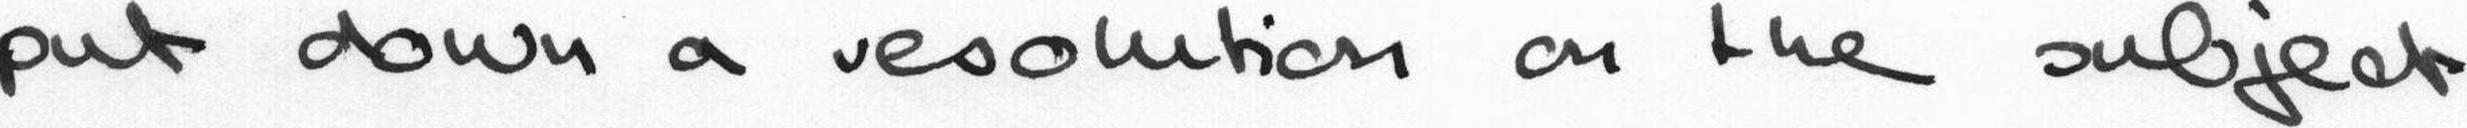

In [54]:
picture = pytorch_small_val_set[0][0]
picture

In [55]:
model_inf.generate(picture)

'1   y   o i i i i r i   i   i   i   i   i   i   i   i   i   i   i   i   o i   i   o i   o i   n  '